In [1]:
import os
from scipy.io import wavfile
import numpy as np
import torch
import librosa
import matplotlib.pyplot as plt

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU. Using CPU only.")
    
# load config file
from whale_gunshot_localization import config
from whale_gunshot_localization.utils.experimental import l2_standardize, MultilaterationOpt, WAVReader
from whale_gunshot_localization.models.tcn_archs import TCNRangeAndClassify
from whale_gunshot_localization.utils.transformations import to_spect

Using the GPU!


helper functions

In [2]:
def convert_range(old_range, new_range, old_value):
    """
    Linearly map a number from one range to another range.

    Parameters
    ----------
    old_range : array-like, shape: 1 X 2
        minimum and maximum of the old number range
    new_range : array-like, shape: 1 X 2
        minimum and maximum of the new number range
    old_value : float
        value to map onto new range
    
    Returns
    -------
    : float
        value mappend onto new range
    """

    old_diff = (old_range[1] - old_range[0])  
    new_diff = (new_range[1] - new_range[0])  
    return (((old_value - old_range[0]) * new_diff) / old_diff) + new_range[0]

## Look Around in Data

search in experimental data

32556.0
34722.0
35501.0
30319.0
29345.0
41986.0
42939.0
38138.0
37022.0
26914.0
27877.0
1864.0
4812.0
31372.0
33678.0
39995.0
25381.0
True
(17, 18000)
['/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/5483/5483.220523170937.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6464/6464.220523163331.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6466/6466.220523162032.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6474/6474.220523174654.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/5816/5816.220523180308.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/5814/5814.220523143227.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6469/6469.220523141634.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/5815/5815.220523153635.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6468/6468.220523155511.wav'
 '/media/mark/extradrive2/SBCE

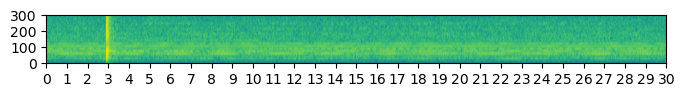

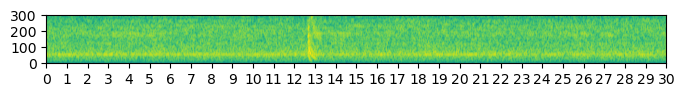

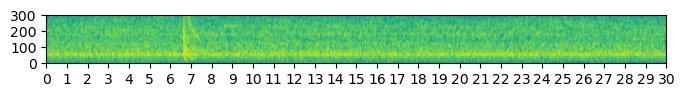

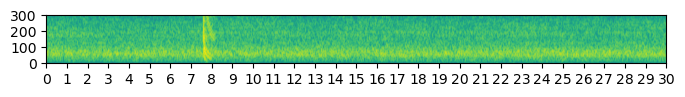

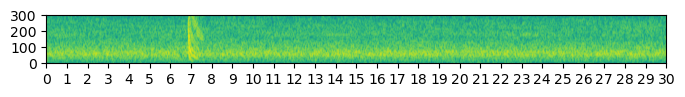

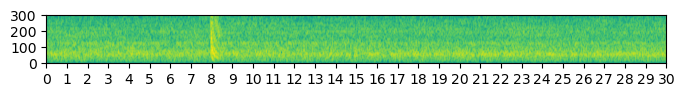

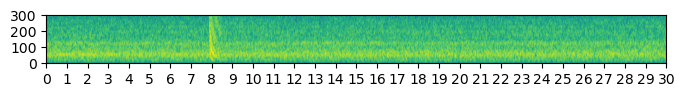

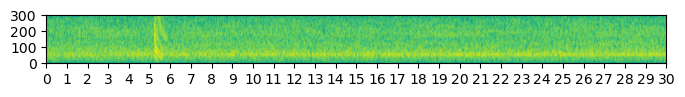

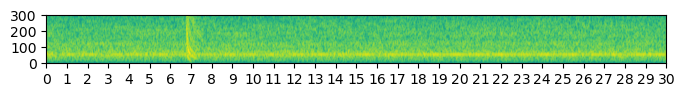

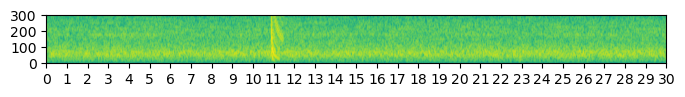

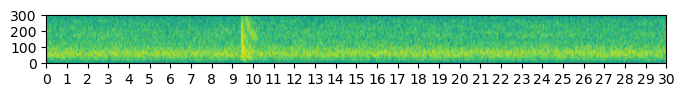

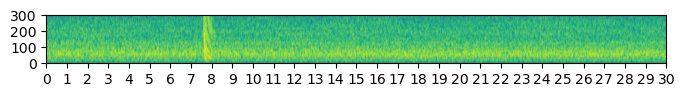

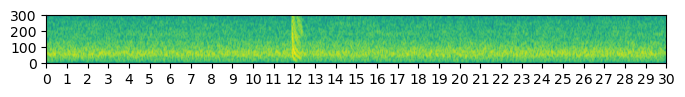

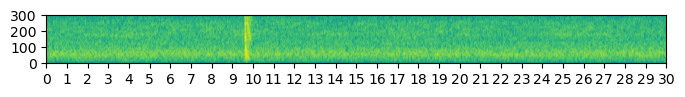

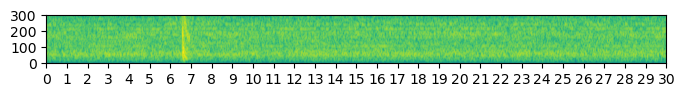

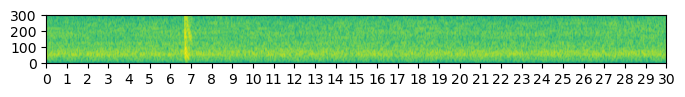

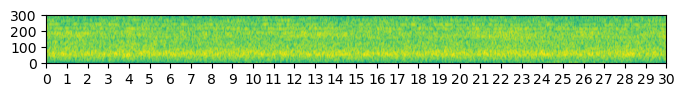

In [20]:
## Settings
chunk_size = 30
timestamp = '2022-05-24T02:12:'

# object to read timestamp from WAV file
WR = WAVReader(sensors=config['TOSSIT']['ids'], chunk_size=chunk_size, fs_desired=config['signal']['fs'])

success, file_list, data = WR.get_audio(timestamp=np.datetime64(timestamp))
print(success)
print(data.shape)
print(file_list)

rows = int(np.floor(np.sqrt(data.shape[0])));
columns = int(np.ceil(data.shape[0]/rows));
# f, axs = plt.subplots(rows,columns)
c = 0
# for ax1 in axs:
#     for ax2 in ax1:
for i in range(17):
    fig = plt.figure()
    ax2 = fig.gca()
    spect = to_spect(data[c,...] - data[c,...].mean()).squeeze()
    ax2.imshow(spect)

    # set x ticks
    x_tick_labels = np.arange(0, chunk_size + 1, 1)
    old_range_x = [0, chunk_size]
    new_range_x = [0, spect.shape[1]]
    ax2.set_xticks([convert_range(old_range_x, new_range_x, val) for val in x_tick_labels])
    ax2.set_xticklabels([int(val) if val.is_integer() else val for val in x_tick_labels])

    # set y ticks
    y_tick_labels = np.arange(0, config['signal']['fs'] / 2 + 1, 100)
    old_range_y = [0, config['signal']['fs'] / 2]
    new_range_y = [0, spect.shape[0]]
    ax2.set_yticks([convert_range(old_range_y, new_range_y, val) for val in y_tick_labels])
    ax2.set_yticklabels(reversed([int(val) if val.is_integer() else val for val in y_tick_labels]))

    c += 1

## Process Data

In [14]:
files = ['gunshot_1_1.wav','gunshot_1_2.wav','gunshot_1_3.wav','gunshot_1_4.wav']

load model

In [15]:
model = TCNRangeAndClassify(input_size=232,          # 232 channel spectrograms
                            num_channels=7*[368],
                            kernel_size=6,
                            dropout=0.3).to(device)

# load model weights
state_dict = torch.load(os.path.join(config['models']['checkpoints_directories'], config['models']['model_dir'], 'weights_best.pt'),
                       map_location=device)['model_state_dict']
model.load_state_dict(state_dict)
model.eval();

load and preprocess audio

Text(0.04, 0.5, 'Frequency [Hz]')

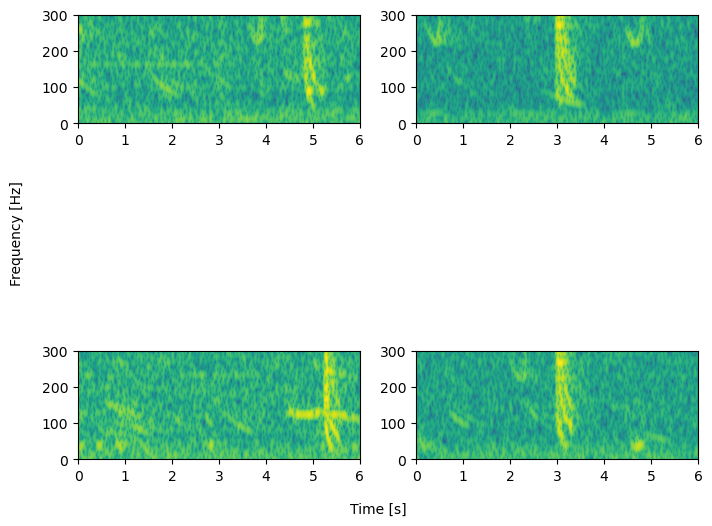

In [30]:
mu_list = np.load(config['dataset']['data_directory'] + '/mean_range_classification.npy', allow_pickle=True)
mu_list = np.expand_dims(mu_list, axis=-1)

std_list = np.load(config['dataset']['data_directory'] + '/std_range_classification.npy', allow_pickle=True)
std_list = np.expand_dims(std_list, axis=-1)

ranges = []
with torch.set_grad_enabled(False):
    for i, f in enumerate(files):
        y,_ = librosa.load(f,sr=600)
        y = l2_standardize(np.expand_dims(y,axis=(0,1)), mu_list, std_list).squeeze(axis=0)
        if i == 0:
            inputs = torch.zeros(len(files),y.shape[1],y.shape[2])
        inputs[i,...] = y
    out = model(inputs.to(device)).squeeze().to('cpu')
ranges = out[:,0]*config['scaling']['max_r']

rows = int(np.floor(np.sqrt(inputs.shape[0])));
columns = int(np.ceil(inputs.shape[0]/rows));
fig, axs = plt.subplots(rows,columns)
c = 0
for ax1 in axs:
    for ax2 in ax1:
        ax2.imshow(inputs[c,...])
        # set x ticks
        x_tick_labels = np.arange(0, config['signal']['T'] + 1, 1)
        old_range_x = [0, config['signal']['T']]
        new_range_x = [0, inputs.shape[2]]
        ax2.set_xticks([convert_range(old_range_x, new_range_x, val) for val in x_tick_labels])
        ax2.set_xticklabels([int(val) if val.is_integer() else val for val in x_tick_labels])

        # set y ticks
        y_tick_labels = np.arange(0, config['signal']['fs'] / 2 + 1, 100)
        old_range_y = [0, config['signal']['fs'] / 2]
        new_range_y = [0, inputs.shape[1]]
        ax2.set_yticks([convert_range(old_range_y, new_range_y, val) for val in y_tick_labels])
        ax2.set_yticklabels(reversed([int(val) if val.is_integer() else val for val in y_tick_labels]))
        c += 1
        
fig.text(0.5, 0.15, 'Time [s]', ha='center')
fig.text(0.04, 0.5, 'Frequency [Hz]', va='center', rotation='vertical')

In [19]:
inputs.shape

torch.Size([4, 232, 601])

In [49]:
def localize(r_p, sensors_idx):
    
    # TOSSITs
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T

    ML = MultilaterationOpt(method_thresh=float('inf'))
    # set geometry
    ML.set_map({
        'TOSSIT_locations' : TOSSIT_locations,
        'min_x' : config['scaling']['min_x'],
        'max_x' : config['scaling']['max_x'],
        'min_y' : config['scaling']['min_y'],
        'max_y' : config['scaling']['max_y'],
    })
        
    _, loc = ML.localize(r_p, sensors_idx)
            
    return loc
loc = localize(np.asarray(ranges), np.asarray([0, 1, 2, 3]))

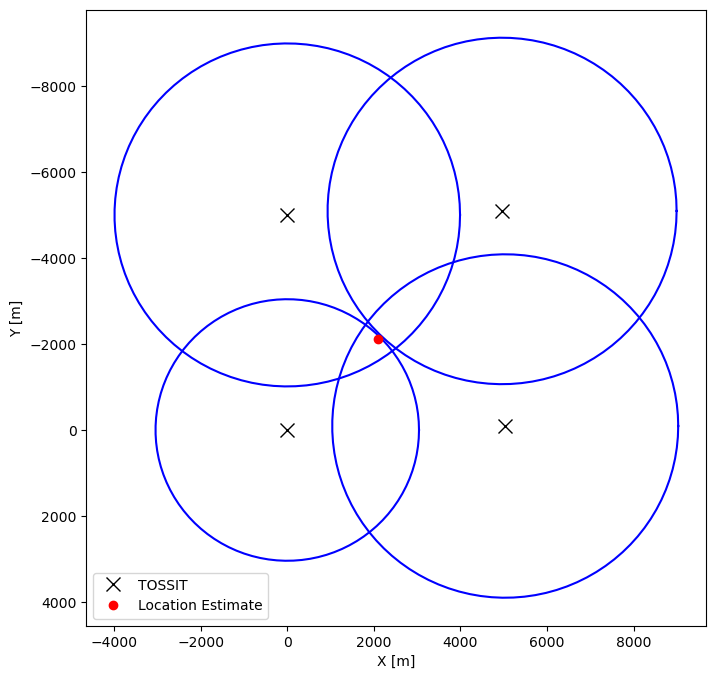

In [50]:
def circle(r, a,b):
    theta = np.linspace(0, 2*np.pi, 100)
    x = r*np.cos(theta) + a
    y = r*np.sin(theta) + b
    return x, y

TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T

plt.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], 'kx', markersize=10, label="TOSSIT")
for idx, r in enumerate(ranges):
    x, y = circle(r, TOSSIT_locations[idx,1], TOSSIT_locations[idx,0])
    plt.plot(x, y, '-b')
plt.plot(loc[1],loc[0],'ro',label="Location Estimate")
plt.gca().invert_yaxis()
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.legend()